In [1]:
%cd ../ 

/mnt/dog/data/indraroy15/2025-MatchCut


In [2]:
from utils.sgg_reltr import * 


/mnt/nas/indraroy15/gatech_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/nas/indraroy15/gatech_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


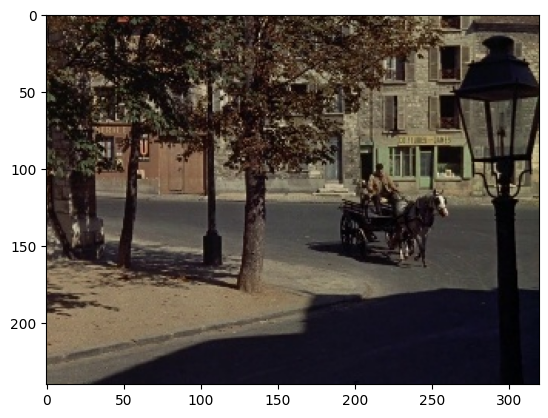

In [3]:
image_path = "./data/netflix_matchcut/data/movienet_netflix_filtered/frame_pos/tt0050706/shot_0021_img_0.jpg"
im = Image.open(image_path)
plt.imshow(im)


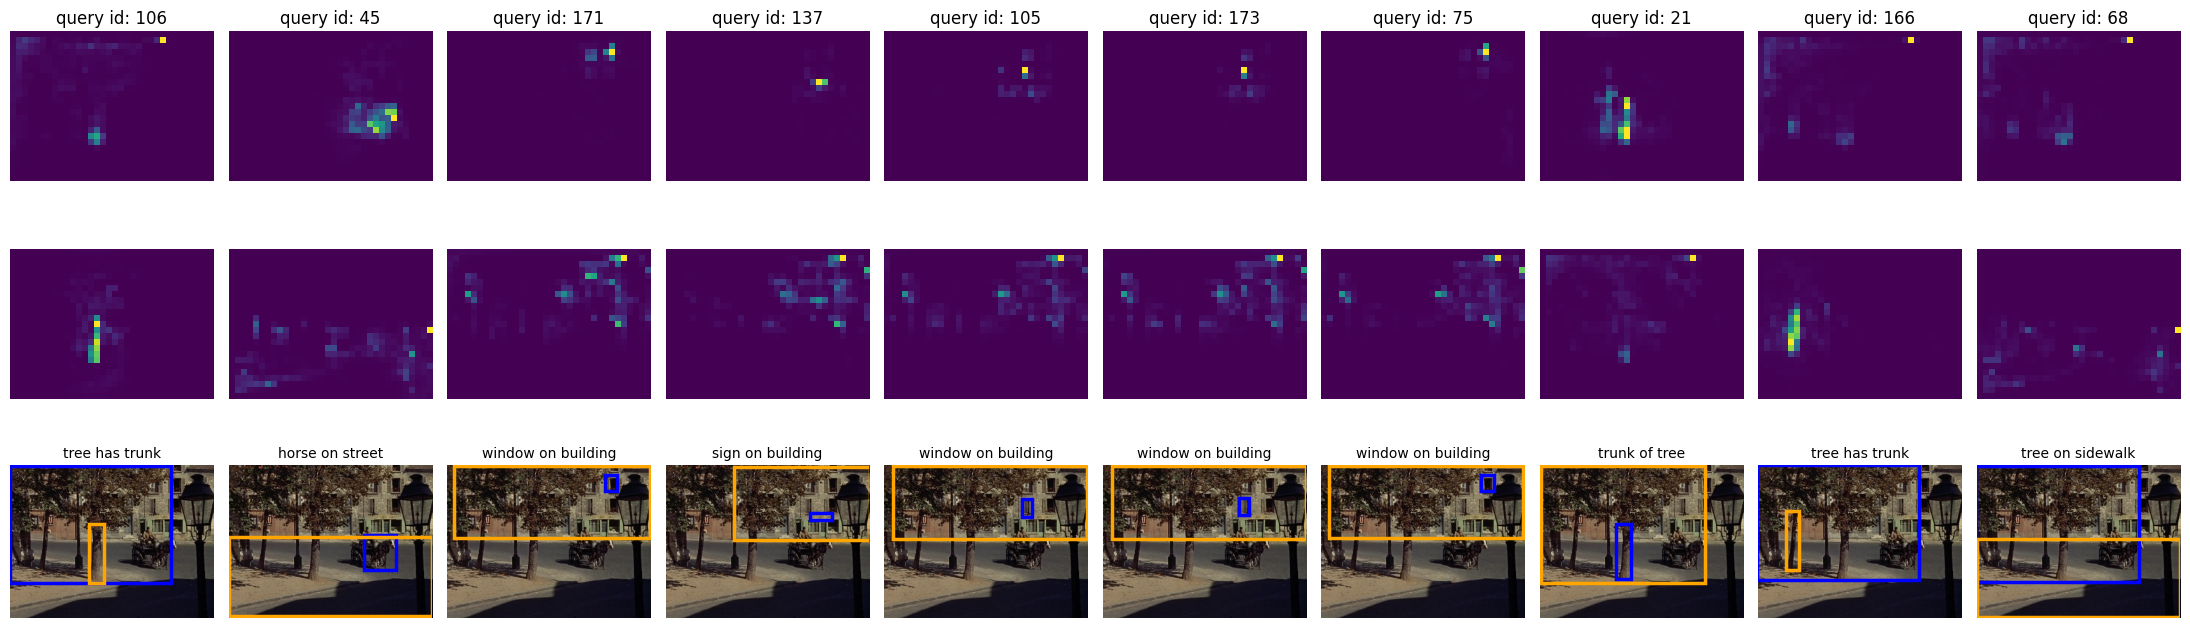

In [4]:
reltr_processing(model, im)

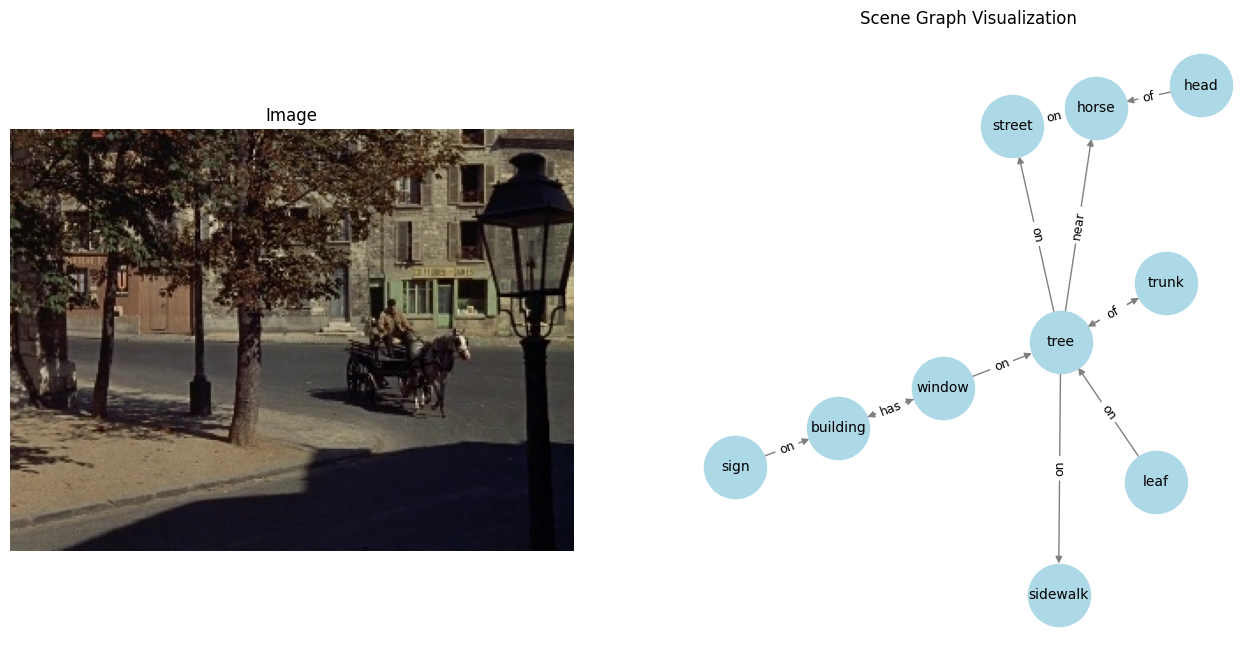

In [6]:
display_scene_graph(model, im, info=False,confidence_threshold=0.3, topk=40)

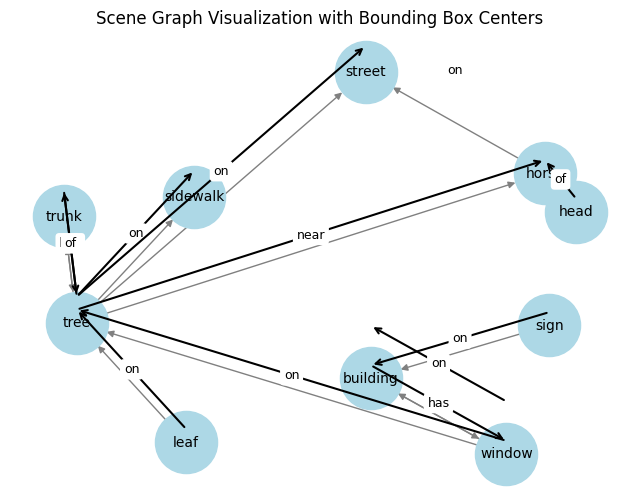

In [21]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# List of relations in the format (subject, relation, object, (sxmin, symin, sxmax, symax), (oxmin, oymin, oxmax, oymax))
# relations = [
#     ("tree", "has", "trunk", (0.9, 2.8, 1.1, 3.2), (0.9, 1.8, 1.1, 2.2)),
#     ("horse", "on", "street", (3.9, 2.8, 4.1, 3.2), (3.9, 1.8, 4.1, 2.2)),
#     ("window", "on", "building", (1.9, 4.8, 2.1, 5.2), (1.9, 3.8, 2.1, 4.2)),
#     ("sign", "on", "building", (2.9, 4.8, 3.1, 5.2), (1.9, 3.8, 2.1, 4.2)),
#     ("window", "on", "building", (2.4, 4.8, 2.6, 5.2), (1.9, 3.8, 2.1, 4.2)),
#     ("window", "on", "building", (2.7, 4.8, 2.9, 5.2), (1.9, 3.8, 2.1, 4.2)),
#     ("window", "on", "building", (3.0, 4.8, 3.2, 5.2), (1.9, 3.8, 2.1, 4.2)),
#     ("trunk", "of", "tree", (0.9, 1.8, 1.1, 2.2), (0.9, 2.8, 1.1, 3.2)),
#     ("tree", "has", "trunk", (0.9, 2.8, 1.1, 3.2), (0.9, 1.8, 1.1, 2.2)),
#     ("tree", "on", "sidewalk", (0.9, 2.8, 1.1, 3.2), (0.9, 0.8, 1.1, 1.2))
# ]

relations = [] 
# [
#     ("tree", "has", "trunk"),
#     ("horse", "on", "street"),
#     ("window", "on", "building"),
#     ("sign", "on", "building"),
#     ("window", "on", "building"),
#     ("window", "on", "building"),
#     ("window", "on", "building"),
#     ("trunk", "of", "tree"),
#     ("tree", "has", "trunk"),
#     ("tree", "on", "sidewalk")
# ]

for idx, (sxmin, symin, sxmax, symax), (oxmin, oymin, oxmax, oymax) in \
            zip(keep_queries, sub_bboxes_scaled[indices], obj_bboxes_scaled[indices]):
    relations.append((CLASSES[probas_sub[idx].argmax()], REL_CLASSES[probas[idx].argmax()], CLASSES[probas_obj[idx].argmax()],(sxmin.item(), symin.item(), sxmax.item(), symax.item()), (oxmin.item(), oymin.item(), oxmax.item(), oymax.item())))

# Create a directed graph
G = nx.DiGraph()
node_positions = {}
edge_labels = {}
edge_count = {}

# Compute node positions based on bounding box centers
for subject, relation, obj, subj_bbox, obj_bbox in relations:
    sxmin, symin, sxmax, symax = subj_bbox
    oxmin, oymin, oxmax, oymax = obj_bbox
    subj_center = ((sxmin + sxmax) / 2, (symin + symax) / 2)
    obj_center = ((oxmin + oxmax) / 2, (oymin + oymax) / 2)
    
    G.add_edge(subject, obj, relation=relation)
    node_positions[subject] = subj_center
    node_positions[obj] = obj_center
    edge_labels[(subject, obj, relation)] = relation
    edge_count[(subject, obj)] = edge_count.get((subject, obj), 0) + 1

# Draw the graph
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Draw nodes and edges
nx.draw(G, node_positions, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2000, font_size=10, ax=ax)

# Draw multiple edges separately
for (u, v, relation), count in edge_labels.items():
    shift = 5 * edge_count[(u, v)]
    x_values = [node_positions[u][0], node_positions[v][0]]
    y_values = [node_positions[u][1] + shift, node_positions[v][1] + shift]
    ax.annotate("", xy=(x_values[1], y_values[1]), xytext=(x_values[0], y_values[0]),
                arrowprops=dict(arrowstyle="->", lw=1.5))
    mid_x, mid_y = (x_values[0] + x_values[1]) / 2, (y_values[0] + y_values[1]) / 2
    plt.text(mid_x, mid_y, relation, fontsize=9, color='black', ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

# Show the figure
plt.title("Scene Graph Visualization with Bounding Box Centers")
plt.show()